# Code to simulate a synthetic GRN and infer the network using TwINFER


## Details about the simulation

### Set this for both running the simulation and before inferring using TwINFER


In [1]:
import numpy as np
root = "/home/mzo5929/Keerthana/grnInference/"

base_config = {
    'n_cells': 5000, #Number of cells before division (number of twin pairs)
    'simulation_time_before_division': 1000, #The time used to run the initial cells before division. User must set this time to ensure the population reaches steady state [hours]
    'twin_simulation_time_after_division': 48, #The time twin cells are simulated after division and measurements are stored in the output[hours]
    'twin_measurement_resolution': 1, #The time between each measurement of twin cells [hours]. For example, if twin_sampling_duration is 12 and twin_measurement_resolution is 1, the final dataframe will contain hourly measurements for 12 hours (0 is birth).
    "path_to_connectivity_matrix": f"{root}/simulation_data/median_parameter_simulations/simulation_details/interaction_matrix_feed_forward.txt", #path to the connectivity matrix specifying the GRN to simulate
    "param_csv": f"{root}/simulation_data/median_parameter_simulations/simulation_details/median_param_3_gene.csv", #Path to the parameters for all genes and interaction terms
    "rows_to_use": [[0, 1, 2]], #Rows in the parameter's csv file for each gene - the length should be equal to number of genes in the system
    "output_folder": f"{root}/simulation_data/median_parameter_simulations/new_simulation", #Path to folder to store simulation 
    "log_file": f"{root}/simulation_data/median_parameter_simulations/simulation_details/median_parameter_simulations.jsonl", #Path to the log file
    "type": "Feed_forward",  # Name of the network used -- will be in the filename
    "number_of_parallel_parameters": 1, #Number of parameters to be run in parallel
    "number_of_cores_per_parameter": 8 #Number of cores to be used per parameter (number_of_parallel_parameters * number_of_cores_per_parameter = number of cores in your computer)
}


## Functions and packages used in this notebook - run this everytime notebook is restarted


### For the simulation


In [9]:
from joblib import Parallel, delayed
from tqdm import tqdm
import os
from tqdm import tqdm
import sys
from numba import set_num_threads, get_num_threads
set_num_threads(base_config['number_of_cores_per_parameter'])
print("Threads Numba will use:", get_num_threads())

from gillespie_script import process_param_set


Threads Numba will use: 8


### For inferring with TwINFER


In [2]:
# Calculation functions
from correlation_analysis_functions import (
    calculate_pairwise_gene_gene_correlation_matrix,
    check_system_in_steady_state,
    check_gene_gene_correlation_threshold,
    calculate_twin_random_pair_correlations,
    differentiate_single_state_reg_and_multiple_states,
    identify_reg_if_multiple_states,
    get_directions_from_simulation
)

# Helper functions
from correlation_analysis_helpers import (
    extract_param_index,
    read_input_matrix,
    get_param_data, 
    plot_matrix_as_heatmap,
    print_summary,
    plot_network
)

import pandas as pd

In [3]:
def infer_using_twinfer(path_to_simulation_file, base_config, t1, t2, 
                        check_for_steady_state=True, 
                        plot_correlation_matrices_as_heatmap=True):
    """
    Infer regulatory interactions in a gene network using twin-based simulation data.

    This function:
    - Loads simulation data and parameter configuration
    - Verifies the simulation file matches expected metadata
    - Identifies potential gene-gene regulatory relationships based on correlation thresholds
    - Distinguishes between single-state regulation and multiple-state behavior
    - Infers directionality of interactions using time-shifted correlations
    - Optionally plots intermediate heatmaps and the final network

    Parameters
    ----------
    path_to_simulation_file : str
        Path to the CSV file containing simulation results.
    base_config : dict
        Configuration dictionary with keys:
            - "n_cells": number of twin clones expected
            - "twin_simulation_time_after_division": total duration after division
            - "twin_measurement_resolution": sampling resolution in hours
            - "path_to_connectivity_matrix": path to GRN connectivity structure
            - "param_csv": path to parameter sets
            - "rows_to_use": list of lists of row indices used in this simulation
    t1 : int
        Time point (in hours) for initial gene-gene correlation.
    t2 : int
        Time point (in hours) for twin/random pair analysis.
    check_for_steady_state : bool, optional
        If True, verifies that system has reached steady state at time `t1`.
    plot_correlation_matrices_as_heatmap : bool, optional
        If True, generates heatmaps of correlation matrices at key stages.

    Returns
    -------
    dict
        A dictionary containing the results of the inference:
        - "direction_matrix": pd.DataFrame
            Directional gene-gene correlation matrix inferred from t1 → t2.
        - "single_state_regulation": list of tuples
            Gene pairs with evidence for single-state regulation.
        - "multi_state_and_reg": list of tuples
            Gene pairs with both multiple states and signs of regulation.
        - "multi_state_no_reg": list of tuples
            Gene pairs with multiple states but no regulatory evidence.
    """

    # Load simulation data
    try:
        simulation = pd.read_csv(path_to_simulation_file)
    except Exception as e:
        raise RuntimeError(f"Error reading the simulation file: {e}")

    # Load connectivity matrix and parameter set
    path_to_connectivity_matrix = base_config["path_to_connectivity_matrix"]
    path_to_parameter_csv = base_config["param_csv"]
    param_df = pd.read_csv(path_to_parameter_csv, index_col=0)

    # --- Basic sanity checks ---
    
    # Assert number of clones in simulation file matches config
    n_clones_simulation = simulation['clone_id'].nunique()
    n_clones_base_config = base_config["n_cells"]
    assert n_clones_simulation == n_clones_base_config, \
        "Number of twin pairs in the simulation file does not match n_cells in base_config."

    # Assert time points match expected resolution
    time_points_simulations = simulation['time_step'].unique()
    time_points_base_config = np.arange(
        0, 
        base_config['twin_simulation_time_after_division'] + base_config['twin_measurement_resolution'], 
        base_config['twin_measurement_resolution']
    )

    assert set(time_points_simulations) == set(time_points_base_config), \
        "The sampling time points in the simulation file do not match those specified in base_config."

    # Assert parameter row identity matches
    param_index_from_file_name = extract_param_index(path_to_simulation_file)
    param_index_from_base_config = "_".join(map(str, base_config["rows_to_use"][0]))
    assert param_index_from_file_name == param_index_from_base_config, \
        "Simulation must match the details in base_config."

    # Load gene parameters and connectivity structure
    gene_params = get_param_data(param_df, param_index_from_file_name)
    n_genes, interaction_matrix = read_input_matrix(path_to_connectivity_matrix)
    gene_list = [f"gene_{i}" for i in np.arange(1, n_genes + 1)]

    # --- Check for steady state at t1 (optional) ---
    if check_for_steady_state:
        is_system_in_steady_state = check_system_in_steady_state(simulation, gene_params, interaction_matrix, gene_list,
                                  relative_diff_threshold=0.05, relative_slope_threshold=0.01)
        if not is_system_in_steady_state:
            raise ValueError(
                "The system is not in steady state. "
                "You can override this by setting check_for_steady_state=False."
            )

    # Ensure the time points t1 and t2 exist in the simulation data
    unique_timepoints = simulation['time_step'].unique()

    if t1 not in unique_timepoints:
        raise ValueError(f"Time point t1={t1} not found in simulation['time_step'].")
    if t2 not in unique_timepoints:
        raise ValueError(f"Time point t2={t2} not found in simulation['time_step'].")

    # Subset the simulation at the desired timepoints
    simulation_t1 = simulation[simulation['time_step'] == t1]
    simulation_t2 = simulation[simulation['time_step'] == t2]

    # --- Step 1: Pairwise gene-gene correlations at t1 ---
    pairwise_gene_gene_correlation_matrix = calculate_pairwise_gene_gene_correlation_matrix(
        simulation_t1, gene_list
    )
    no_regulation, potential_regulation = check_gene_gene_correlation_threshold(
        pairwise_gene_gene_correlation_matrix, gene_list
    )
    # print(no_regulation)
    if plot_correlation_matrices_as_heatmap:
        plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix, gene_list=gene_list, no_regulation=no_regulation, potential_regulation=potential_regulation,
            title=f"Gene-gene correlations at time {t1}h", add_gene_labels=True, add_time=False, gray_out_no_reg=False
        )

    # --- Step 2: Twin/random correlations at t2 ---
    twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
        simulation_t2, gene_list
    )
    # print(twin_pair_correlation_matrix_t2)
    if plot_correlation_matrices_as_heatmap:
        plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t2, gene_list=gene_list, no_regulation=no_regulation, potential_regulation=potential_regulation,
            title=f"Twin pair correlations at time {t2}h", add_gene_labels=True, add_time=True, time=[t2], gray_out_no_reg=True
        )
        
        plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t2, gene_list=gene_list, no_regulation=no_regulation, potential_regulation=potential_regulation,
            title=f"Random pair correlations at time {t2}h", add_gene_labels=True, add_time=True, time=[t2], gray_out_no_reg=True
        )

    # --- Step 3: Classify regulation type: single-state vs multiple-states ---
    multiple_states_gene_pairs, single_state_regulation = differentiate_single_state_reg_and_multiple_states(
        potential_regulation, twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2, gene_list
    )

    if len(multiple_states_gene_pairs) > 0:
        twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1 = calculate_twin_random_pair_correlations(
            simulation, t1, gene_list
        )
        multiple_states_no_reg, multiple_states_and_reg = identify_reg_if_multiple_states(
            twin_pair_correlation_matrix_t1,twin_pair_correlation_matrix_t2,random_pair_correlation_matrix_t1,
            random_pair_correlation_matrix_t2,multiple_states_gene_pairs,gene_list
            )
    else:
        multiple_states_no_reg, multiple_states_and_reg = [], []

    # --- Step 4: Print summary of results ---
    print_summary(no_regulation, single_state_regulation, multiple_states_no_reg, multiple_states_and_reg)
    
    # --- Step 5: Infer directionality of single-state interactions ---
    direction_raw_matrix, direction_normalized_matrix, pre_threshold_direction_matrix = get_directions_from_simulation(simulation_t1, simulation_t2, gene_pairs=single_state_regulation, threshold=0.02)
    # print(pre_threshold_direction_matrix)

    if plot_correlation_matrices_as_heatmap:
        # Mark all (i, j) entries where direction could not be determined
        undirected_pairs = [
            (g1, g2)
            for g1 in direction_normalized_matrix.index
            for g2 in direction_normalized_matrix.columns
            if (g1, g2) not in single_state_regulation
        ]

        plot_matrix_as_heatmap(
            corr_matrix=direction_normalized_matrix,
            gene_list=list(direction_normalized_matrix.index),
            no_regulation=undirected_pairs,                   
            potential_regulation=single_state_regulation,     
            title=f"Directional correlations (from {t1}h to {t2}h)",
            add_gene_labels=True,
            add_time=True,
            time=[t1, t2],
            gray_out_no_reg=True
        )

    # --- Step 6: Visualize the inferred network ---
    plot_network(direction_normalized_matrix, gene_list)

    return {
    "direction_matrix": direction_normalized_matrix,
    "single_state_regulation": single_state_regulation,
    "multi_state_and_reg": multiple_states_and_reg,
    "multi_state_no_reg": multiple_states_no_reg
    }

## Simulate the gene expression in a population of cells

The code simulates gene expression based on a GRN (described by the interaction matrix) and expression of each gene is defined by parameters (each row in the parameter sheet) using the Gillespie algorithm.


In [ ]:
os.makedirs(base_config['output_folder'], exist_ok=True)
rows_to_use = base_config['rows_to_use']
labels = ["rows_" + "_".join(map(str, row)) for row in rows_to_use]
param_sets = list(zip(rows_to_use, labels))

# ✅ Run over specified number of jobs (workers)
results = Parallel(n_jobs=base_config['number_of_parallel_parameters'])(
    delayed(process_param_set)(rows, label, base_config)
    for rows, label in tqdm(param_sets, total=len(param_sets), desc="All iterations")
)

# ✅ Print results (matching the concurrent.futures style)
for (rows, label), res in zip(param_sets, results):
    print(f"Completed simulation for {label} (rows={rows}): {res}")

# Using TwINFER to infer network from the simulation

### Before starting, set the time-points used as t1 and t2. The default is 1 hour and 10 hours after division.

TwINFER uses three kinds of correlations used for distinguishing multiple-states and regulation.

- First, calculate gene-gene correlations $\rho$ for all pairs of genes at time t1. This will identify gene-pairs that are potentially interacting.
- Second, calculate twin pair correlation $\hat{\rho}_{\Delta}$ and random pair correlation. Comparing these two for all gene pairs will detect the existence of multiple states in the population vs just regulation.
- Finally, if there are multiple states in the population, compare twin pair correlation $\hat{\rho}_{\Delta}$ at time t1 and time t2. This will detect the existence of regulatory interaction.

Next, if there is regulation and single-state in the population, TwINFER can identify direction of regulatory interaction. This is done be comparing cross-correlations between twins at the two timepoints.

### Based on this algorithm, a network will be inferred and plotted.


### Input to TwINFER


In [8]:
t1 = 1 #time [hours] after division when t1 sample is collected
t2 = 10 #time [hours] after division when t2 sample is collected

#This should be the simulation matching the details in base_config
#path to the simulation output file - this will be printed at the end of the simulation
path_to_simulation_file = "/home/mzo5929/Keerthana/grnInference//simulation_data/median_parameter_simulations/new_simulation/df_rows_0_1_2_29072025_173447_ncells_5000_Feed_forward_b64a8f7c.csv" 

### Run TwINFER for inference using the simulation, base_config, t1 and t2.



1. No Regulation
  (none)

2. Single-State Regulation
  gene_1 - gene_2
  gene_1 - gene_3
  gene_2 - gene_1
  gene_2 - gene_3
  gene_3 - gene_1
  gene_3 - gene_2

3. Multiple States (No Regulation)
  (none)

4. Multiple States with Regulation
  (none)
['gene_1', 'gene_2', 'gene_3']
gene_1 gene_2
['gene_1', 'gene_2', 'gene_3']
gene_1 gene_3
['gene_1', 'gene_2', 'gene_3']
gene_2 gene_1
['gene_1', 'gene_2', 'gene_3']
gene_2 gene_3
['gene_1', 'gene_2', 'gene_3']
gene_3 gene_1
['gene_1', 'gene_2', 'gene_3']
gene_3 gene_2


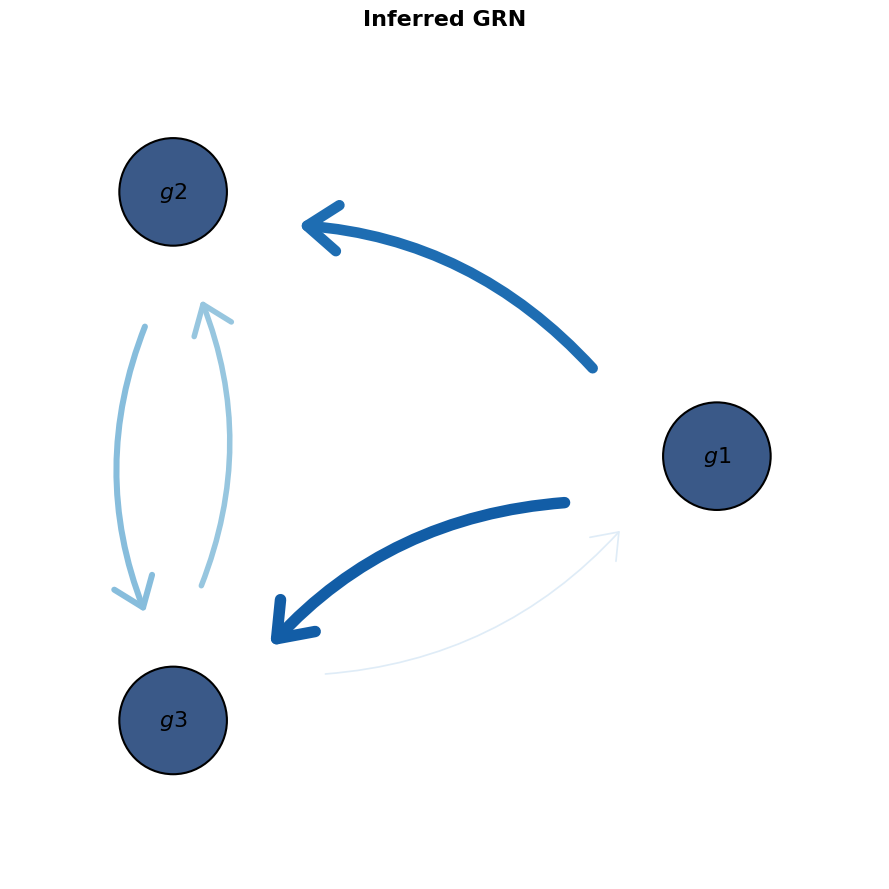

{'direction_matrix':           gene_1    gene_2    gene_3
 gene_1  1.000000  0.762321  0.825106
 gene_2  0.000000  1.000000  0.435812
 gene_3  0.121697  0.397565  1.000000,
 'single_state_regulation': [('gene_1', 'gene_2'),
  ('gene_1', 'gene_3'),
  ('gene_2', 'gene_1'),
  ('gene_2', 'gene_3'),
  ('gene_3', 'gene_1'),
  ('gene_3', 'gene_2'),
  ('gene_2', 'gene_2'),
  ('gene_1', 'gene_1'),
  ('gene_3', 'gene_3')],
 'multi_state_and_reg': [],
 'multi_state_no_reg': []}

In [10]:
infer_using_twinfer(path_to_simulation_file, base_config, t1, t2, 
                        check_for_steady_state=True, 
                        plot_correlation_matrices_as_heatmap=False)

## Generating two-state populations from the simulation data

To create a two (or multi) state population, read the simulation files for different populations and merge them.
